# Verde River: Uncertainties in Future Reservoir Change Predictions

In [9]:
from datetime import datetime
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

rs = 123 #Fix random state for reproducibility
uf = 60.3/1000 #Conversion factor from cu ft/s to 1000 acre-feet per 30 days

In [10]:
df = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
season_length = 12
test_size = int(8.5 * season_length) # Set aside the last 8.5 years as our ultimate testing set.
df_train = df[:-test_size]
df_test = df[-test_size:]

#Individual prediction uncertainties, copied and hard-coded
verde_up_err = 0.15
verde_down_err = 0.51

The following is redundant code to generate the future upstream and downstream flow predictions

In [11]:
verde_upstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_11"
]

target = "log_flow_verde_upstream"
all_cols_needed = verde_upstream_features + [target]
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

verde_upstream_model = GradientBoostingRegressor(max_depth=3, n_estimators=100, random_state=rs)
verde_upstream_model.fit(df_model_train[verde_upstream_features], df_model_train[target])

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [12]:
verde_downstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_verde_upstream",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6"
]

target = "log_flow_verde_downstream"
all_cols_needed = verde_downstream_features + [target]
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

verde_downstream_model = XGBRegressor(max_depth=6, n_estimators=100, random_state=rs)
verde_downstream_model.fit(df_model_train[verde_downstream_features], df_model_train[target])

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [13]:
# Load historical and future data sets
df_history = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
df_future_245 = pd.read_csv("../Data/FormattedData/FutureVals_SSP245Climate_and_AllOtherFeatures.csv").head(120)
df_future_585 = pd.read_csv("../Data/FormattedData/FutureVals_SSP585Climate_and_AllOtherFeatures.csv").head(120) #Keep only 10 years for future predictions

# Define the columns we want to keep from the historical data
extra_historical_targets = ["log_flow_verde_upstream","log_flow_verde_downstream"]
history_columns_to_keep = list(df_future_245.columns) + extra_historical_targets

# Extract the top 20 rows with the designated features
df_history_top20 = df_history.tail(20)[history_columns_to_keep].copy()

# Combine historical and pojected future data vertically
# Note: Pandas automatically pads the future rows with NaN under the target columns
df_combined_245 = pd.concat([df_history_top20, df_future_245], axis=0).reset_index(drop=True)
df_combined_585 = pd.concat([df_history_top20, df_future_585], axis=0).reset_index(drop=True)

# Create lag columns
df_combined_245["log_flow_verde_upstream_lag_1"] = df_combined_245["log_flow_verde_upstream"].shift(1)
df_combined_245["log_flow_verde_upstream_lag_11"] = df_combined_245["log_flow_verde_upstream"].shift(11)
df_combined_245["log_flow_verde_downstream_lag_5"] = df_combined_245["log_flow_verde_downstream"].shift(5)
df_combined_245["log_flow_verde_downstream_lag_6"] = df_combined_245["log_flow_verde_downstream"].shift(6)

df_combined_585["log_flow_verde_upstream_lag_1"] = df_combined_585["log_flow_verde_upstream"].shift(1)
df_combined_585["log_flow_verde_upstream_lag_11"] = df_combined_585["log_flow_verde_upstream"].shift(11)
df_combined_585["log_flow_verde_downstream_lag_5"] = df_combined_585["log_flow_verde_downstream"].shift(5)
df_combined_585["log_flow_verde_downstream_lag_6"] = df_combined_585["log_flow_verde_downstream"].shift(6)

In [14]:

for i in range(12,len(df_combined_245.Time)):
    df_combined_245.loc[i,'log_flow_verde_upstream_lag_1'] = df_combined_245.loc[i-1,'log_flow_verde_upstream']
    df_combined_245.loc[i,'log_flow_verde_upstream_lag_11'] = df_combined_245.loc[i-11,'log_flow_verde_upstream']
    df_combined_245.loc[i,'log_flow_verde_upstream'] = verde_upstream_model.predict(df_combined_245[verde_upstream_features].iloc[[i]])[0]
    
    df_combined_245.loc[i,'log_flow_verde_downstream_lag_5'] = df_combined_245.loc[i-5,'log_flow_verde_downstream']
    df_combined_245.loc[i,'log_flow_verde_downstream_lag_6'] = df_combined_245.loc[i-6,'log_flow_verde_downstream']
    df_combined_245.loc[i,'log_flow_verde_downstream'] = verde_downstream_model.predict(df_combined_245[verde_downstream_features].iloc[[i]])[0]
    

for i in range(12,len(df_combined_585.Time)):
    df_combined_585.loc[i,'log_flow_verde_upstream_lag_1'] = df_combined_585.loc[i-1,'log_flow_verde_upstream']
    df_combined_585.loc[i,'log_flow_verde_upstream_lag_11'] = df_combined_585.loc[i-11,'log_flow_verde_upstream']
    df_combined_585.loc[i,'log_flow_verde_upstream'] = verde_upstream_model.predict(df_combined_585[verde_upstream_features].iloc[[i]])[0]

    df_combined_585.loc[i,'log_flow_verde_downstream_lag_5'] = df_combined_585.loc[i-5,'log_flow_verde_downstream']
    df_combined_585.loc[i,'log_flow_verde_downstream_lag_6'] = df_combined_585.loc[i-6,'log_flow_verde_downstream']
    df_combined_585.loc[i,'log_flow_verde_downstream'] = verde_downstream_model.predict(df_combined_585[verde_downstream_features].iloc[[i]])[0]

Calculating the uncertainties in the future reservoir change predictions

In [15]:
#Back tranforming log flow to original scale and then taking the difference
df_combined_585['flow_verde_upstream']   = np.expm1(df_combined_585["log_flow_verde_upstream"])
df_combined_585['flow_verde_downstream'] = np.expm1(df_combined_585["log_flow_verde_downstream"])
df_combined_245['flow_verde_upstream']   = np.expm1(df_combined_245["log_flow_verde_upstream"])
df_combined_245['flow_verde_downstream'] = np.expm1(df_combined_245["log_flow_verde_downstream"])

#Calculate difference between inflow and outflow
df_combined_585["difference_flow"] = df_combined_585["flow_verde_upstream"] - df_combined_585["flow_verde_downstream"]
df_combined_245["difference_flow"] = df_combined_245["flow_verde_upstream"] - df_combined_245["flow_verde_downstream"]

#Individual predicted flow difference values
df_combined_585['abs_error_sq'] = (df_combined_585['flow_verde_upstream']*verde_up_err)**2 + (df_combined_585['flow_verde_downstream']*verde_down_err)**2
df_combined_245['abs_error_sq'] = (df_combined_245['flow_verde_upstream']*verde_up_err)**2 + (df_combined_245['flow_verde_downstream']*verde_down_err)**2

#Quadratic sum of individual uncertainties to get cumulative uncertainties
df_combined_585['abs_error_cu'] = np.sqrt(df_combined_585['abs_error_sq'].cumsum()) * uf
df_combined_245['abs_error_cu'] = np.sqrt(df_combined_245['abs_error_sq'].cumsum()) * uf

#Calculating cumulative difference in inflow and outflow
df_combined_585["CumDiff_flow"] = df_combined_585["difference_flow"].cumsum() * uf
df_combined_245["CumDiff_flow"] = df_combined_245["difference_flow"].cumsum() * uf

#Calculate upper and lower bounds for confidence intervals
df_combined_585['CumDiff_high'] = df_combined_585['CumDiff_flow'] + df_combined_585['abs_error_cu']
df_combined_585['CumDiff_low']  = df_combined_585['CumDiff_flow'] - df_combined_585['abs_error_cu']
df_combined_245['CumDiff_high'] = df_combined_245['CumDiff_flow'] + df_combined_245['abs_error_cu']
df_combined_245['CumDiff_low']  = df_combined_245['CumDiff_flow'] - df_combined_245['abs_error_cu']


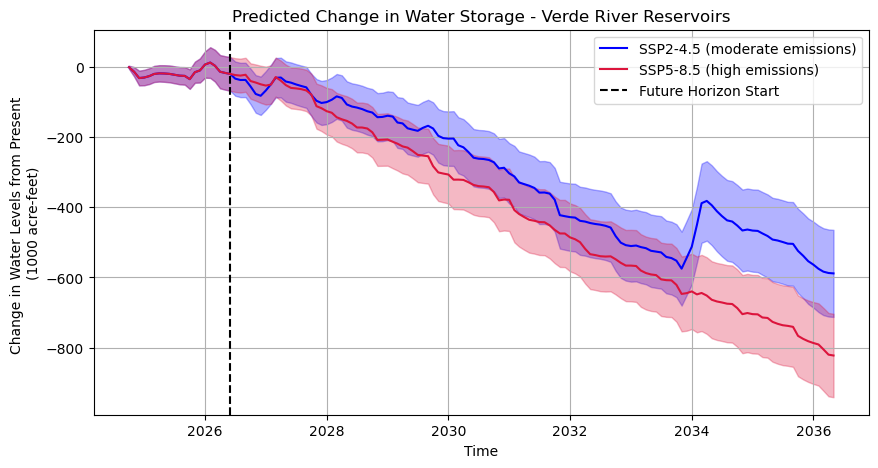

In [16]:

plt.figure(figsize=(10, 5))

plt.plot(
    pd.to_datetime(df_combined_245["Time"]), 
    df_combined_245["CumDiff_flow"], 
    label="SSP2-4.5 (moderate emissions)", 
    color="blue")
plt.fill_between(pd.to_datetime(df_combined_245['Time']),
                 df_combined_245['CumDiff_high'], df_combined_245['CumDiff_low'],
                 color='blue', alpha=0.3)
plt.plot(
    pd.to_datetime(df_combined_585["Time"]), 
    df_combined_585["CumDiff_flow"], 
    label="SSP5-8.5 (high emissions)", 
    color="crimson")
plt.fill_between(pd.to_datetime(df_combined_585['Time']),
                 df_combined_585['CumDiff_high'], df_combined_585['CumDiff_low'],
                 color='crimson', alpha=0.3)
plt.axvline(pd.to_datetime(df_combined_585["Time"].iloc[20]), color="black", linestyle="--", label="Future Horizon Start")
plt.title("Predicted Change in Water Storage - Verde River Reservoirs")
plt.ylabel("Change in Water Levels from Present \n(1000 acre-feet)")
plt.xlabel("Time")
plt.grid(True)
plt.legend()

plt.savefig(
    "../Output/PredictedCumulativeChange_VerdeEB.png",
    dpi=300,
    bbox_inches="tight")

plt.show()